# ASL Detection

## Imports & Setup

In [ ]:
import os, urllib.request
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

!pip install mediapipe
import mediapipe as mp
from mediapipe.tasks import python as mp_tasks
from mediapipe.tasks.python import vision as mp_vision

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from collections import Counter
import seaborn as sns

DEVICE = torch.device("mps" if torch.backends.mps.is_available()
                      else "cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
print(f"MediaPipe version: {mp.__version__}")

Using device: mps
MediaPipe version: 0.10.32


## Download grassknoted/asl-alphabet dataset

In [ ]:
!pip install kaggle

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()  # Uses ~/.kaggle/kaggle.json

DOWNLOAD_DIR = "./data"
if not TRAIN_DIR.exists():
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    print("Downloading grassknoted/asl-alphabet (~1 GB) ...")
    api.dataset_download_files("grassknoted/asl-alphabet", path=DOWNLOAD_DIR, unzip=True)
    print(f"Done. Dataset at: {TRAIN_DIR}")
else:
    print(f"Dataset already present: {TRAIN_DIR}")

# Verify classes
classes = sorted([d.name for d in TRAIN_DIR.iterdir()
                  if d.is_dir() and d.name in TARGET_CLASSES])
NUM_CLASSES = len(classes)
le = LabelEncoder().fit(classes)
print(f"Classes ({NUM_CLASSES}): {classes}")

## Paths, Config & Download Hand Landmarker model

In [ ]:
TRAIN_DIR        = Path("data/asl_alphabet_train/asl_alphabet_train")
MODEL_PATH       = Path("asl_landmark_mlp.pth")
NPZ_CACHE        = Path("landmark_features.npz")
LANDMARKER_MODEL = Path("hand_landmarker.task")

EPOCHS       = 40
BATCH_SIZE   = 512
LR           = 1e-3
VAL_SPLIT    = 0.15
NUM_FEATURES = 21 * 3   # 21 landmarks x (x, y, z)

# Only A-Z (skip "del", "nothing", "space" from grassknoted dataset)
TARGET_CLASSES = [chr(c) for c in range(ord('A'), ord('Z') + 1)]

# Download the hand landmarker model if not present
if not LANDMARKER_MODEL.exists():
    print("Downloading hand_landmarker.task ...")
    url = "https://storage.googleapis.com/mediapipe-models/hand_landmarker/hand_landmarker/float16/1/hand_landmarker.task"
    urllib.request.urlretrieve(url, LANDMARKER_MODEL)
    print("Downloaded.")
else:
    print(f"Model already present: {LANDMARKER_MODEL}")


!pip install kaggle

from kaggle.api.kaggle_api_extended import KaggleApi

api = KaggleApi()
api.authenticate()  # Uses ~/.kaggle/kaggle.json

DOWNLOAD_DIR = "./data"
if not TRAIN_DIR.exists():
    os.makedirs(DOWNLOAD_DIR, exist_ok=True)
    print("Downloading grassknoted/asl-alphabet (~1 GB) ...")
    api.dataset_download_files("grassknoted/asl-alphabet", path=DOWNLOAD_DIR, unzip=True)
    print(f"Done. Dataset at: {TRAIN_DIR}")
else:
    print(f"Dataset already present: {TRAIN_DIR}")

# Verify classes
classes = sorted([d.name for d in TRAIN_DIR.iterdir()
                  if d.is_dir() and d.name in TARGET_CLASSES])
NUM_CLASSES = len(classes)
le = LabelEncoder().fit(classes)
print(f"Classes ({NUM_CLASSES}): {classes}")


Model already present: hand_landmarker.task


## Cell 5 — Extract landmarks from all training images

In [ ]:
def make_landmarker(model_path: Path, mode=mp_vision.RunningMode.IMAGE):
    """Create a HandLandmarker using the MediaPipe Tasks API."""
    base_opts = mp_tasks.BaseOptions(model_asset_path=str(model_path))
    opts = mp_vision.HandLandmarkerOptions(
        base_options=base_opts,
        running_mode=mode,
        num_hands=1,
        min_hand_detection_confidence=0.3,
        min_hand_presence_confidence=0.3,
        min_tracking_confidence=0.3,
    )
    return mp_vision.HandLandmarker.create_from_options(opts)

def apply_clahe(img_bgr):
    """Improve contrast on dark images using CLAHE on the L channel."""
    lab = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
    lab[:, :, 0] = clahe.apply(lab[:, :, 0])
    return cv2.cvtColor(lab, cv2.COLOR_LAB2BGR)

def extract_landmarks_from_dataset(train_dir: Path, cache_path: Path,
                                   target_classes: list[str]):
    """Extract hand landmarks from dataset. Uses cache if available."""
    if cache_path.exists():
        print(f"Loading cached features from {cache_path} ...")
        data = np.load(cache_path, allow_pickle=True)
        return data["X"], data["y"]

    landmarker = make_landmarker(LANDMARKER_MODEL)
    X, y = [], []

    class_dirs = sorted([d for d in train_dir.iterdir()
                         if d.is_dir() and d.name in target_classes])
    total = sum(len(list(d.glob("*.jpg"))) for d in class_dirs)
    done, detected = 0, 0
    print(f"Extracting landmarks from {total} images ({len(class_dirs)} classes)...")

    for class_dir in class_dirs:
        label = class_dir.name
        for img_path in class_dir.glob("*.jpg"):
            img_bgr = cv2.imread(str(img_path))
            if img_bgr is None:
                done += 1
                continue

            # CLAHE to handle dark images
            img_bgr = apply_clahe(img_bgr)
            img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
            mp_img  = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
            result  = landmarker.detect(mp_img)

            if result.hand_landmarks:
                lm  = result.hand_landmarks[0]
                row = np.array([[p.x, p.y, p.z] for p in lm],
                               dtype=np.float32).flatten()
                X.append(row)
                y.append(label)
                detected += 1

            done += 1
            if done % 2000 == 0:
                rate = detected / done * 100
                print(f"  {done}/{total} processed, {detected} detected ({rate:.1f}%) ...")

    landmarker.close()
    X = np.array(X, dtype=np.float32)
    y = np.array(y)
    np.savez_compressed(cache_path, X=X, y=y)
    print(f"\nDone! {detected}/{done} images had landmarks ({detected/done*100:.1f}%)")
    print(f"Saved {len(X)} samples -> {cache_path}")
    return X, y

X_raw, y_str = extract_landmarks_from_dataset(TRAIN_DIR, NPZ_CACHE, TARGET_CLASSES)

# Refit LabelEncoder on actually-extracted classes
classes = sorted(set(y_str))
NUM_CLASSES = len(classes)
le = LabelEncoder().fit(classes)
print(f"Classes after extraction ({NUM_CLASSES}): {classes}")

y = le.transform(y_str).astype(np.int64)
print(f"Feature matrix: {X_raw.shape}  Labels: {y.shape}")


I0000 00:00:1773275483.654248 10691421 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1773275483.661486 10691424 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773275483.671793 10691424 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Extracting landmarks from 78000 images (26 classes)...
  2000/78000 processed, 1208 detected (60.4%) ...
  4000/78000 processed, 2322 detected (58.1%) ...
  6000/78000 processed, 3329 detected (55.5%) ...
  8000/78000 processed, 4147 detected (51.8%) ...
  10000/78000 processed, 5127 detected (51.3%) ...
  12000/78000 processed, 6245 detected (52.0%) ...
  14000/78000 processed, 7345 detected (52.5%) ...
  16000/78000 processed, 8535 detected (53.3%) ...
  18000/78000 processed, 9758 detected (54.2%) ...
  20000/78000 processed, 10989 detected (54.9%) ...
  22000/78000 processed, 12070 detected (54.9%) ...
  24000/78000 processed, 13144 detected (54.8%) ...
  26000/78000 processed, 14034 detected (54.0%) ...
  28000/78000 processed, 14983 detected (53.5%) ...
  30000/78000 processed, 16104 detected (53.7%) ...
  32000/78000 processed, 17342 detected (54.2%) ...
  34000/78000 processed, 18520 detected (54.5%) ...
  36000/78000 processed, 19619 detected (54.5%) ...
  38000/78000 processe

## Visualise landmarks on a sample image

I0000 00:00:1773277334.403800 10722639 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1773277334.413567 10722640 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773277334.428009 10722640 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


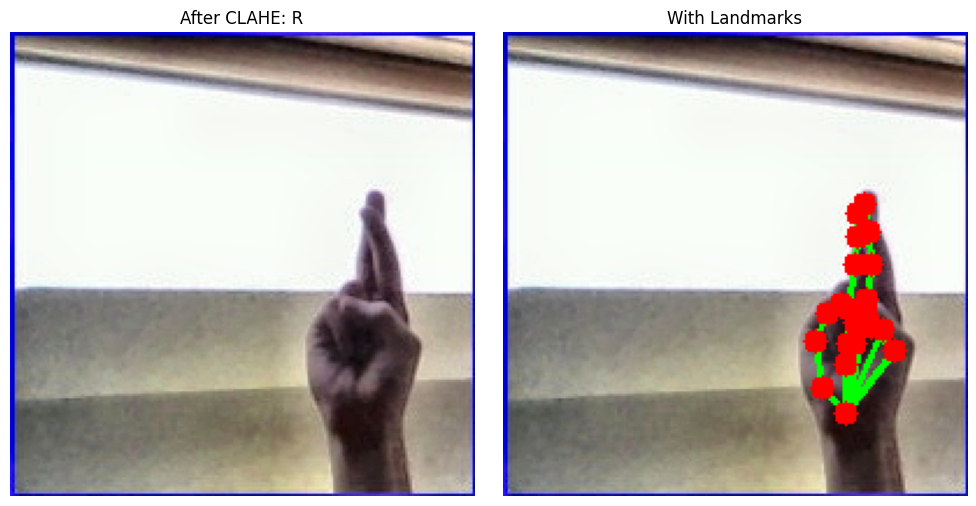

In [ ]:

HAND_CONNECTIONS = [
    (0,1),(1,2),(2,3),(3,4),
    (0,5),(5,6),(6,7),(7,8),
    (0,9),(9,10),(10,11),(11,12),
    (0,13),(13,14),(14,15),(15,16),
    (0,17),(17,18),(18,19),(19,20),
    (5,9),(9,13),(13,17),
]

def draw_landmarks_cv(frame, landmarks):
    """Draw 21 keypoints + skeleton on a BGR frame (in-place)."""
    h, w = frame.shape[:2]
    pts = [(int(lm.x * w), int(lm.y * h)) for lm in landmarks]
    for i, j in HAND_CONNECTIONS:
        cv2.line(frame, pts[i], pts[j], (0, 255, 0), 2)
    for pt in pts:
        cv2.circle(frame, pt, 5, (0, 0, 255), -1)

# Grab a sample
sample_class = next(d for d in TRAIN_DIR.iterdir()
                    if d.is_dir() and d.name in TARGET_CLASSES)
sample_path = next(sample_class.glob("*.jpg"))

img_bgr = apply_clahe(cv2.imread(str(sample_path)))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

landmarker_vis = make_landmarker(LANDMARKER_MODEL)
mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
res = landmarker_vis.detect(mp_img)
landmarker_vis.close()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_rgb)
axes[0].set_title(f"After CLAHE: {sample_class.name}")
axes[0].axis("off")

annotated = img_bgr.copy()
if res.hand_landmarks:
    draw_landmarks_cv(annotated, res.hand_landmarks[0])
    axes[1].imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    axes[1].set_title("With Landmarks")
else:
    axes[1].imshow(img_rgb)
    axes[1].set_title("No hand detected")
axes[1].axis("off")
plt.tight_layout()
plt.show()


## Data Pipeline with Augmentation

In [ ]:
class HandDataset(torch.utils.data.Dataset):
    def __init__(self, X, y, augment=False):
        self.X = X
        self.y = y
        self.augment = augment

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        landmarks = self.X[idx].reshape(21, 3).copy()

        if self.augment:
            # Random rotation (in-plane, +/-15 degrees)
            theta = np.radians(np.random.uniform(-15, 15))
            c, s = np.cos(theta), np.sin(theta)
            rot = np.array(((c, -s, 0), (s, c, 0), (0, 0, 1)))
            landmarks = landmarks @ rot

            # Random scale (+/-10%)
            landmarks *= np.random.uniform(0.9, 1.1)

            # Random jitter
            landmarks += np.random.normal(0, 0.002, landmarks.shape)

        # Normalize: center on wrist, scale to unit max distance
        landmarks -= landmarks[0]
        max_dist = np.linalg.norm(landmarks, axis=1).max()
        if max_dist > 0:
            landmarks /= max_dist

        return landmarks.flatten().astype(np.float32), self.y[idx]

# Filter singleton classes (can't stratify)
counts = Counter(y)
valid = np.array([counts[yi] >= 2 for yi in y])
X_filtered, y_filtered = X_raw[valid], y[valid]
n_removed = len(y) - len(y_filtered)
if n_removed > 0:
    print(f"Filtered out {n_removed} samples from singleton classes")

# Split
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_filtered, y_filtered, test_size=VAL_SPLIT, random_state=42, stratify=y_filtered
)

train_dataset = HandDataset(X_train_raw, y_train, augment=True)
val_dataset   = HandDataset(X_val_raw,   y_val,   augment=False)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)

print(f"Train: {len(train_dataset)}  Val: {len(val_dataset)}")


Train: 36249  Val: 6398


## MLP Classifier

In [ ]:
class LandmarkMLP(nn.Module):
    def __init__(self, in_features: int, num_classes: int):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(256, 128),
            nn.ReLU(),

            nn.Linear(128, num_classes),
        )

    def forward(self, x):
        return self.net(x)

model = LandmarkMLP(NUM_FEATURES, NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters: {total_params:,}")
print(model)


Parameters: 201,882
LandmarkMLP(
  (net): Sequential(
    (0): Linear(in_features=63, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): ReLU()
    (10): Linear(in_features=128, out_features=26, bias=True)
  )
)


## Training Loop

In [ ]:
model = LandmarkMLP(NUM_FEATURES, NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss(label_smoothing=0.05)
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

def run_epoch(loader, training: bool):
    model.train() if training else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    ctx = torch.enable_grad() if training else torch.no_grad()
    with ctx:
        for feats, labels in loader:
            feats, labels = feats.to(DEVICE), labels.to(DEVICE)
            if training:
                optimizer.zero_grad()
            logits = model(feats)
            loss = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * feats.size(0)
            correct    += (logits.argmax(1) == labels).sum().item()
            total      += feats.size(0)
    return total_loss / total, correct / total

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_acc = 0.0

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = run_epoch(train_loader, training=True)
    vl_loss, vl_acc = run_epoch(val_loader,   training=False)
    scheduler.step()
    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)
    print(f"Epoch {epoch:02d}/{EPOCHS} | "
          f"Train {tr_loss:.4f}/{tr_acc:.3f} | Val {vl_loss:.4f}/{vl_acc:.3f}")
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save({"model": model.state_dict(), "classes": classes}, MODEL_PATH)
        print(f"  -> Best model saved (val_acc={best_val_acc:.3f})")

print(f"\nBest val accuracy: {best_val_acc:.3f}")


Epoch 01/40 | Train 1.2536/0.768 | Val 0.6316/0.926
  -> Best model saved (val_acc=0.926)
Epoch 02/40 | Train 0.6443/0.923 | Val 0.5580/0.942
  -> Best model saved (val_acc=0.942)
Epoch 03/40 | Train 0.5926/0.934 | Val 0.5246/0.954
  -> Best model saved (val_acc=0.954)
Epoch 04/40 | Train 0.5681/0.941 | Val 0.5039/0.956
  -> Best model saved (val_acc=0.956)
Epoch 05/40 | Train 0.5462/0.947 | Val 0.4930/0.960
  -> Best model saved (val_acc=0.960)
Epoch 06/40 | Train 0.5367/0.949 | Val 0.4887/0.959
Epoch 07/40 | Train 0.5252/0.952 | Val 0.4851/0.961
  -> Best model saved (val_acc=0.961)
Epoch 08/40 | Train 0.5184/0.953 | Val 0.4725/0.965
  -> Best model saved (val_acc=0.965)
Epoch 09/40 | Train 0.5097/0.956 | Val 0.4708/0.964
Epoch 10/40 | Train 0.5045/0.958 | Val 0.4696/0.963
Epoch 11/40 | Train 0.4996/0.959 | Val 0.4630/0.966
  -> Best model saved (val_acc=0.966)
Epoch 12/40 | Train 0.4943/0.960 | Val 0.4615/0.966
Epoch 13/40 | Train 0.4912/0.961 | Val 0.4561/0.969
  -> Best model save

## Training curves + sklearn evaluation

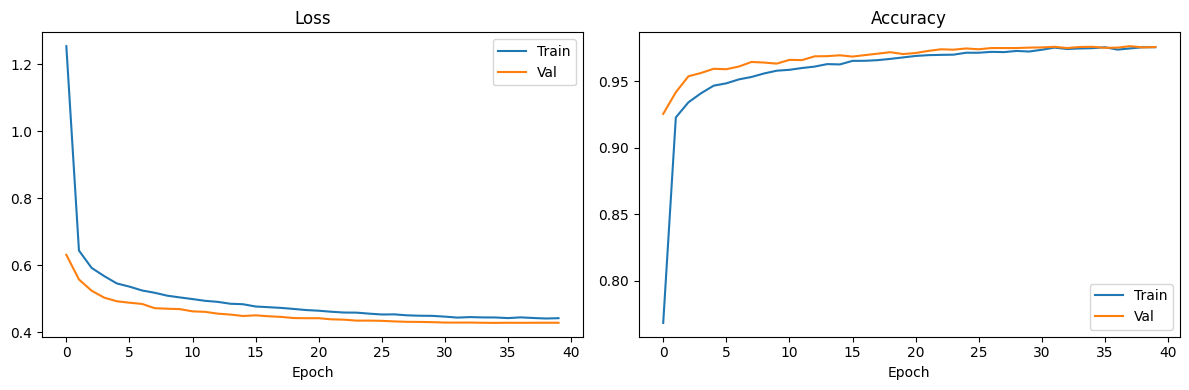

              precision    recall  f1-score   support

           A       0.98      0.97      0.97       273
           B       1.00      0.99      0.99       227
           C       0.96      0.99      0.97       181
           D       0.97      0.96      0.96       257
           E       1.00      0.98      0.99       253
           F       0.99      0.99      0.99       274
           G       1.00      0.99      0.99       270
           H       1.00      1.00      1.00       237
           I       0.91      0.96      0.94       196
           J       0.97      0.96      0.97       248
           K       1.00      0.97      0.98       284
           L       0.98      0.96      0.97       243
           M       0.87      0.95      0.91       117
           N       0.88      0.95      0.91        98
           O       0.98      0.98      0.98       252
           P       1.00      0.97      0.98       212
           Q       0.98      1.00      0.99       244
           R       0.97    

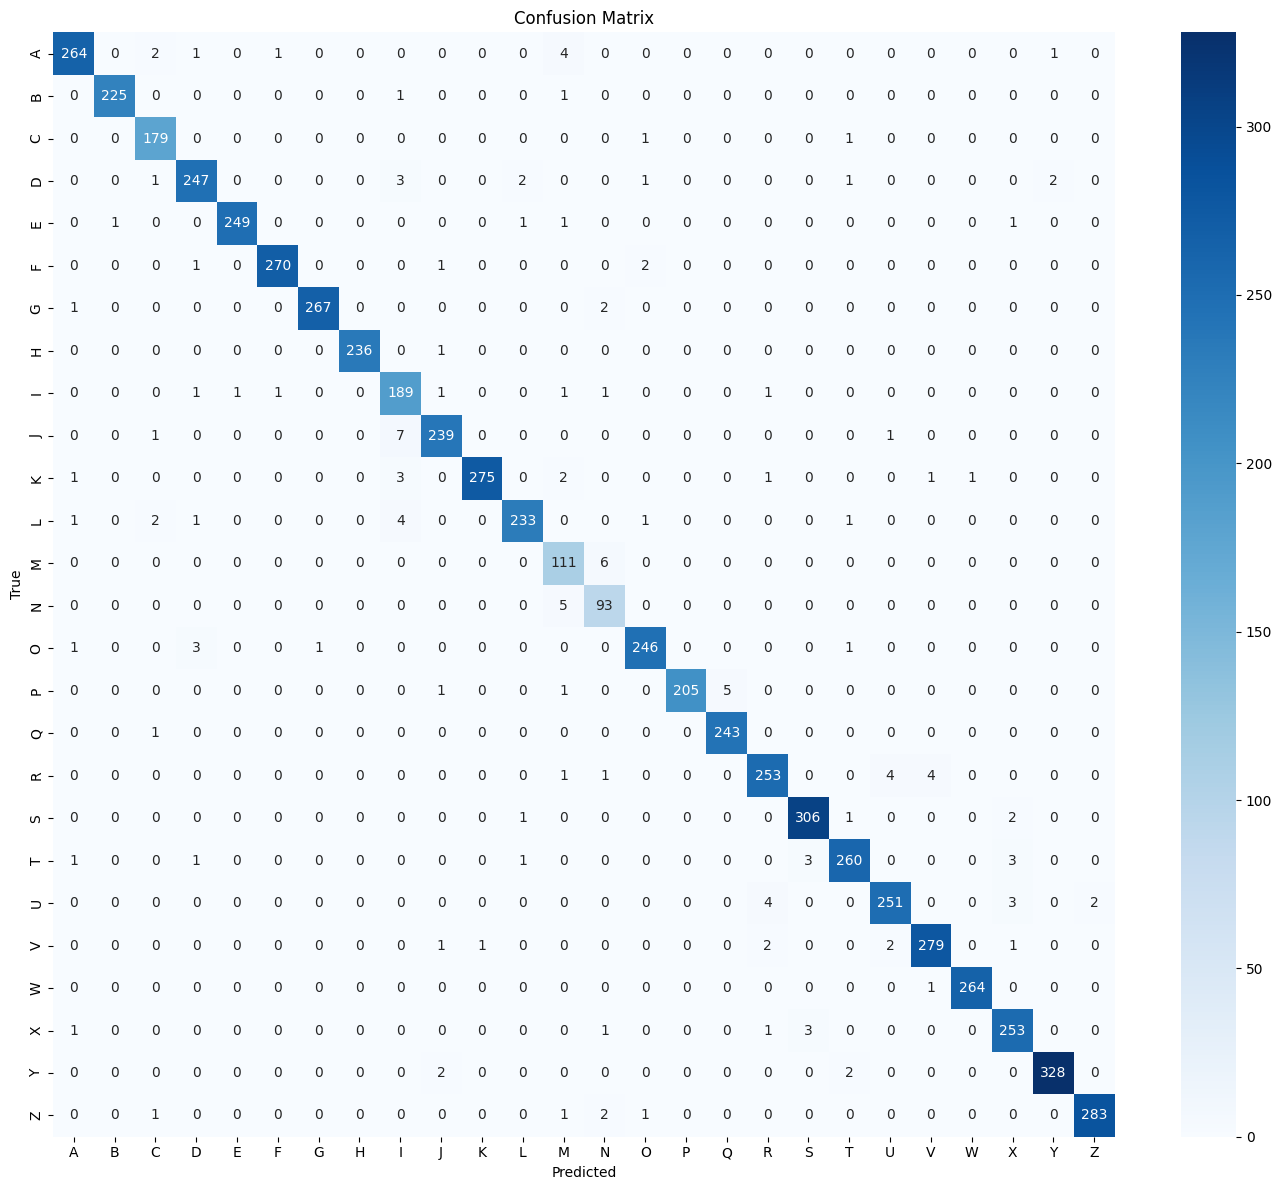

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history["train_loss"], label="Train")
ax1.plot(history["val_loss"],   label="Val")
ax1.set(title="Loss", xlabel="Epoch"); ax1.legend()
ax2.plot(history["train_acc"], label="Train")
ax2.plot(history["val_acc"],   label="Val")
ax2.set(title="Accuracy", xlabel="Epoch"); ax2.legend()
plt.tight_layout(); plt.show()

# Load best checkpoint
ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"])
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for feats, labels in val_loader:
        logits = model(feats.to(DEVICE))
        all_preds.extend(logits.argmax(1).cpu().numpy())
        all_labels.extend(labels.numpy())

print(classification_report(all_labels, all_preds, target_names=classes))

cm = confusion_matrix(all_labels, all_preds)
fig, ax = plt.subplots(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt="d", xticklabels=classes, yticklabels=classes,
            cmap="Blues", ax=ax)
ax.set(xlabel="Predicted", ylabel="True", title="Confusion Matrix")
plt.tight_layout(); plt.show()


## Local Webcam Inference

In [48]:
ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model"])
model.eval()
classes = ckpt["classes"]

def normalise_row(landmarks) -> np.ndarray:
    row = np.array([[p.x, p.y, p.z] for p in landmarks], dtype=np.float32)
    row -= row[0]
    scale = np.linalg.norm(row, axis=1).max()
    if scale > 0:
        row /= scale
    return row.flatten()

def predict_landmarks(landmarks) -> tuple[str, float]:
    feat = normalise_row(landmarks)
    tensor = torch.from_numpy(feat).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1)[0]
    conf, idx = probs.max(0)
    return classes[idx.item()], conf.item()

cap = cv2.VideoCapture(0)
if not cap.isOpened():
    print("ERROR: Cannot open webcam.")
else:
    landmarker_live = make_landmarker(LANDMARKER_MODEL, mode=mp_vision.RunningMode.IMAGE)
    print("Webcam opened. Press 'q' to quit.")

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        img_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        mp_img = mp.Image(image_format=mp.ImageFormat.SRGB, data=img_rgb)
        result = landmarker_live.detect(mp_img)

        if result.hand_landmarks:
            lm = result.hand_landmarks[0]
            draw_landmarks_cv(frame, lm)
            label, conf = predict_landmarks(lm)
            cv2.putText(frame, f"{label} ({conf:.0%})", (10, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.2, (0, 255, 0), 3)
        else:
            cv2.putText(frame, "No hand detected", (10, 50),
                        cv2.FONT_HERSHEY_SIMPLEX, 1, (0, 0, 255), 2)

        cv2.imshow("ASL Detection", frame)
        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

    landmarker_live.close()
    cap.release()
    cv2.destroyAllWindows()
    print("Webcam released.")


I0000 00:00:1773280308.561603 10770341 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 90.5), renderer: Apple M1 Pro
W0000 00:00:1773280308.570405 10770346 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1773280308.584730 10770344 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Webcam opened. Press 'q' to quit.
Webcam released.
